# UPI Shield AI — Notebook 2: Exploratory Data Analysis

## Objective

The objective of this notebook is to perform Exploratory Data Analysis on the PaySim online transaction fraud dataset.

In Notebook 1, we understood the dataset structure, missing values, duplicate values, transaction types, and class imbalance.

In this notebook, we will use visualizations to answer important questions:

1. How imbalanced is the fraud class?
2. Which transaction types are more related to fraud?
3. Are fraud transactions generally higher in amount?
4. What balance patterns are visible in fraud transactions?
5. Does sender balance becoming zero indicate suspicious behavior?
6. Are there useful patterns that can help us create new features?

This notebook will help us prepare for Notebook 3: Feature Engineering.

In [ ]:
# ---------------------------------------------------------
# Step 1: Import Required Libraries
# ---------------------------------------------------------
# We import libraries for data loading, visualization,
# numerical operations, and warning handling.

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# Basic chart style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ---------------------------------------------------------
# Step 2: Mount Google Drive
# ---------------------------------------------------------
# We mount Google Drive to access the dataset from our project folder.

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
# ---------------------------------------------------------
# Step 3: Define Project Paths
# ---------------------------------------------------------
# These paths help us load the raw dataset and save reports/images.

BASE_DIR = "/content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring"

RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
SCREENSHOTS_DIR = os.path.join(BASE_DIR, "screenshots")

DATA_PATH = os.path.join(RAW_DATA_DIR, "onlinefraud.csv")

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

print("Dataset Path:", DATA_PATH)
print("Reports Directory:", REPORTS_DIR)
print("Screenshots Directory:", SCREENSHOTS_DIR)

Dataset Path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/data/raw/onlinefraud.csv
Reports Directory: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports
Screenshots Directory: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/screenshots


In [ ]:
# ---------------------------------------------------------
# Step 4: Load Dataset
# ---------------------------------------------------------
# We load the original dataset for analysis.
# Since the dataset is large, loading may take some time.

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.6400,C1231006815,170136.0000,160296.3600,M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,1864.2800,C1666544295,21249.0000,19384.7200,M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1,0
4,1,PAYMENT,11668.1400,C2048537720,41554.0000,29885.8600,M1230701703,0.0000,0.0000,0,0


In [ ]:
# ---------------------------------------------------------
# Step 5: Create Development Sample for Fast EDA
# ---------------------------------------------------------
# The dataset contains more than 6 million records.
# For faster visualizations, we create a development sample:
#
# 1. Keep all fraud transactions.
# 2. Randomly select 100,000 normal transactions.
# 3. Combine and shuffle them.
#
# This gives us a useful sample without losing fraud cases.

fraud_df = df[df["isFraud"] == 1]
normal_df = df[df["isFraud"] == 0]

normal_sample = normal_df.sample(n=100000, random_state=42)

eda_df = pd.concat([fraud_df, normal_sample], axis=0)
eda_df = eda_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Full dataset shape:", df.shape)
print("Fraud records in full dataset:", fraud_df.shape[0])
print("Normal sample records:", normal_sample.shape[0])
print("EDA sample shape:", eda_df.shape)

eda_df.head()

Full dataset shape: (6362620, 11)
Fraud records in full dataset: 8213
Normal sample records: 100000
EDA sample shape: (108213, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,284,PAYMENT,2295.9800,C1799658065,0.0000,0.0000,M1888808576,0.0000,0.0000,0,0
1,133,CASH_IN,120287.9400,C749056708,1666154.2900,1786442.2300,C1338686176,4554705.7500,4434417.8100,0,0
2,692,TRANSFER,471086.3000,C1237394124,0.0000,0.0000,C710564759,611927.5100,1083013.8100,0,0
3,298,CASH_OUT,123429.8600,C264963194,0.0000,0.0000,C1811291679,706827.0700,830256.9300,0,0
4,134,CASH_OUT,120410.6500,C1654380606,0.0000,0.0000,C623388952,3280374.4400,3400785.0900,0,0


In [ ]:
# ---------------------------------------------------------
# Step 6: Compare Full Dataset and EDA Sample Class Distribution
# ---------------------------------------------------------
# We compare class distribution in full data and EDA sample
# so we clearly understand the difference.

full_distribution = df["isFraud"].value_counts().rename(index={0: "Normal", 1: "Fraud"})
sample_distribution = eda_df["isFraud"].value_counts().rename(index={0: "Normal", 1: "Fraud"})

distribution_comparison = pd.DataFrame({
    "Full Dataset Count": full_distribution,
    "EDA Sample Count": sample_distribution
})

distribution_comparison

,Full Dataset Count,EDA Sample Count
isFraud,,
Normal,6354407,100000
Fraud,8213,8213


## Note on EDA Sampling

The original dataset contains more than 6 million transactions. Visualizing the full dataset repeatedly can be slow in Google Colab.

For faster EDA, we created a development sample by keeping all fraud transactions and randomly selecting 100,000 normal transactions.

This sample is only for visualization and understanding patterns.

For model training and evaluation, we will carefully handle sampling and class imbalance in later notebooks.

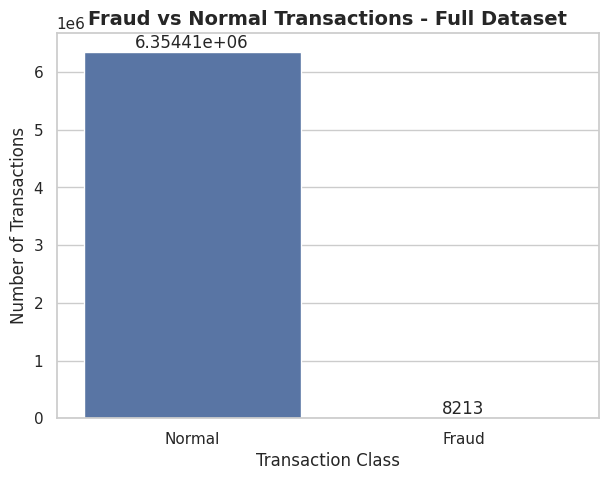

In [ ]:
# ---------------------------------------------------------
# Step 7: Fraud vs Normal Count Plot - Full Dataset
# ---------------------------------------------------------
# This plot shows the original class imbalance in the complete dataset.

plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="isFraud")

plt.title("Fraud vs Normal Transactions - Full Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Normal", "Fraud"])

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
# ---------------------------------------------------------
# Step 8: Fraud Percentage - Full Dataset
# ---------------------------------------------------------
# This table shows how rare fraud transactions are.

fraud_percentage_full = df["isFraud"].value_counts(normalize=True) * 100

fraud_percentage_table = pd.DataFrame({
    "Class": ["Normal", "Fraud"],
    "Percentage": [
        fraud_percentage_full.get(0, 0),
        fraud_percentage_full.get(1, 0)
    ]
})

fraud_percentage_table

,Class,Percentage
0,Normal,99.8709
1,Fraud,0.1291


## Observation

The dataset is highly imbalanced. Fraud transactions are very rare compared to normal transactions.

This means accuracy alone will not be a reliable metric for this project.

In model evaluation, we must focus on:

- Recall
- Precision
- F1-score
- ROC-AUC
- Confusion Matrix

For fraud detection, recall is very important because missing an actual fraud transaction is risky.

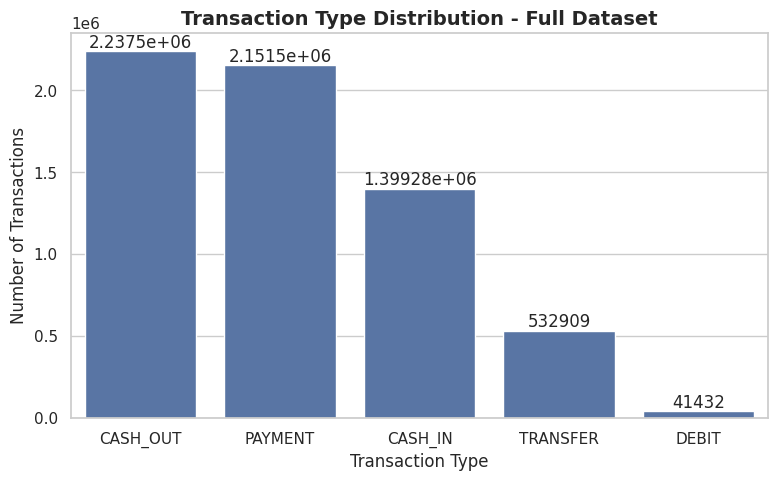

In [ ]:
# ---------------------------------------------------------
# Step 9: Transaction Type Distribution
# ---------------------------------------------------------
# This plot shows how many transactions belong to each type.

plt.figure(figsize=(9, 5))

ax = sns.countplot(data=df, x="type", order=df["type"].value_counts().index)

plt.title("Transaction Type Distribution - Full Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
# ---------------------------------------------------------
# Step 10: Transaction Type Percentage Table
# ---------------------------------------------------------
# This table shows transaction type distribution in count
# and percentage form.

type_counts = df["type"].value_counts()
type_percentage = df["type"].value_counts(normalize=True) * 100

type_summary = pd.DataFrame({
    "Transaction Count": type_counts,
    "Percentage": type_percentage
})

type_summary

,Transaction Count,Percentage
type,,
CASH_OUT,2237500,35.1663
PAYMENT,2151495,33.8146
CASH_IN,1399284,21.9923
TRANSFER,532909,8.3756
DEBIT,41432,0.6512


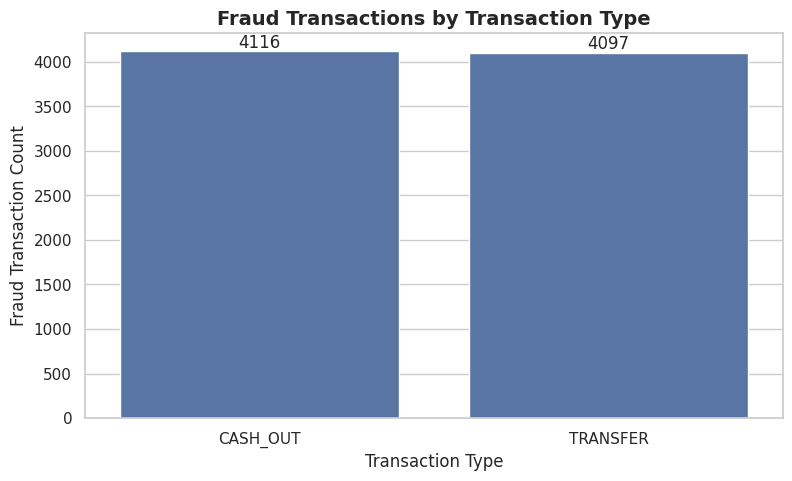

In [ ]:
# ---------------------------------------------------------
# Step 11: Fraud Count by Transaction Type
# ---------------------------------------------------------
# This plot shows which transaction types contain fraud cases.

fraud_type_data = df[df["isFraud"] == 1]

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=fraud_type_data,
    x="type",
    order=fraud_type_data["type"].value_counts().index
)

plt.title("Fraud Transactions by Transaction Type", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Transaction Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
# ---------------------------------------------------------
# Step 12: Fraud Percentage by Transaction Type
# ---------------------------------------------------------
# This table shows fraud percentage for each transaction type.
# It helps identify high-risk transaction types.

fraud_by_type = df.groupby("type")["isFraud"].agg(["count", "sum"])

fraud_by_type = fraud_by_type.rename(columns={
    "count": "Total Transactions",
    "sum": "Fraud Transactions"
})

fraud_by_type["Fraud Percentage"] = (
    fraud_by_type["Fraud Transactions"] / fraud_by_type["Total Transactions"]
) * 100

fraud_by_type = fraud_by_type.sort_values(by="Fraud Percentage", ascending=False)

fraud_by_type

,Total Transactions,Fraud Transactions,Fraud Percentage
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237500,4116,0.1840
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


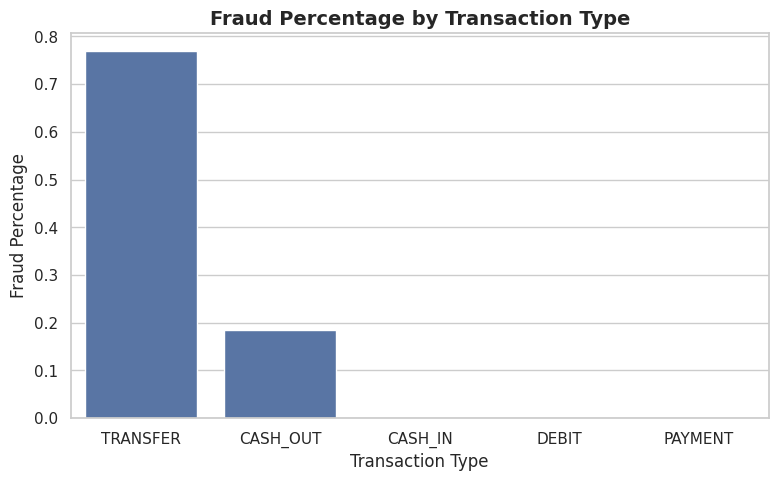

In [ ]:
# ---------------------------------------------------------
# Step 13: Fraud Percentage by Transaction Type Plot
# ---------------------------------------------------------
# This plot helps us visually compare risk across transaction types.

plt.figure(figsize=(9, 5))

sns.barplot(
    x=fraud_by_type.index,
    y=fraud_by_type["Fraud Percentage"]
)

plt.title("Fraud Percentage by Transaction Type", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Percentage")

plt.show()

## Observation

Fraud transactions are not equally distributed across all transaction types.

Some transaction types are more important for fraud detection than others.

This suggests that `type` will be an important feature during model training.

In the next notebook, we will encode the `type` column using one-hot encoding.

In [ ]:
# ---------------------------------------------------------
# Step 14: Transaction Amount Summary
# ---------------------------------------------------------
# This compares amount statistics for normal and fraud transactions.

amount_summary = df.groupby("isFraud")["amount"].describe()
amount_summary.index = ["Normal Transactions", "Fraud Transactions"]

amount_summary

,count,mean,std,min,25%,50%,75%,max
Normal Transactions,6354407.0000,178197.0417,596236.9813,0.0100,13368.3950,74684.7200,208364.7600,92445516.6400
Fraud Transactions,8213.0000,1467967.2991,2404252.9472,0.0000,127091.3300,441423.4400,1517771.4800,10000000.0000


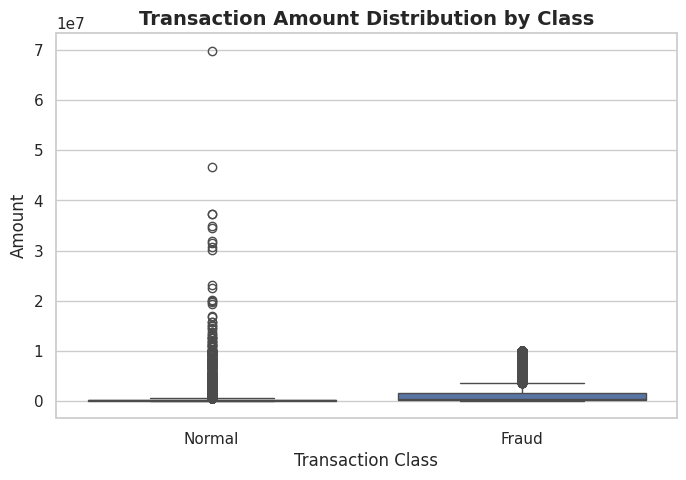

In [ ]:
# ---------------------------------------------------------
# Step 15: Transaction Amount Boxplot by Fraud Class
# ---------------------------------------------------------
# This boxplot compares transaction amount distribution
# between normal and fraud transactions.

plt.figure(figsize=(8, 5))

sns.boxplot(data=eda_df, x="isFraud", y="amount")

plt.title("Transaction Amount Distribution by Class", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Amount")
plt.xticks([0, 1], ["Normal", "Fraud"])

plt.show()

In [ ]:
# ---------------------------------------------------------
# Step 16: Create Log Amount for Better Visualization
# ---------------------------------------------------------
# Transaction amount can be highly skewed.
# log1p is used because it handles zero values safely.
#
# log1p(x) = log(1 + x)

eda_df["log_amount"] = np.log1p(eda_df["amount"])

eda_df[["amount", "log_amount"]].head()

,amount,log_amount
0,2295.9800,7.7394
1,120287.9400,11.6977
2,471086.3000,13.0628
3,123429.8600,11.7234
4,120410.6500,11.6987


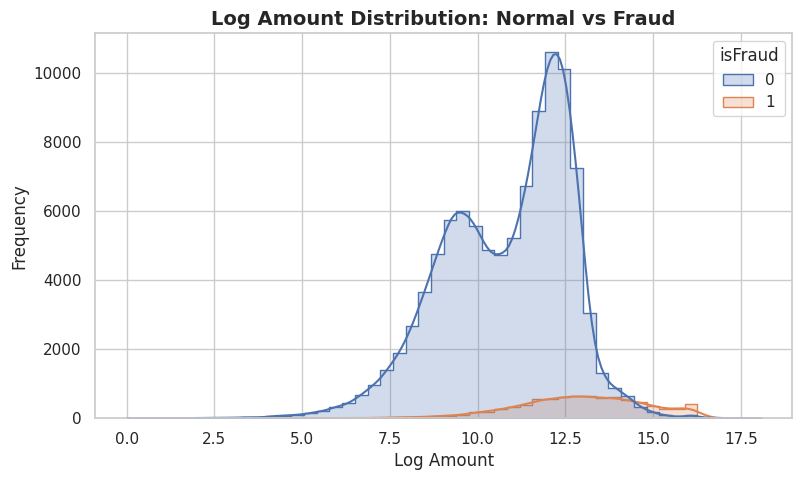

In [ ]:
# ---------------------------------------------------------
# Step 17: Log Amount Distribution by Fraud Class
# ---------------------------------------------------------
# This plot helps compare amount patterns clearly after
# reducing skewness using log transformation.

plt.figure(figsize=(9, 5))

sns.histplot(
    data=eda_df,
    x="log_amount",
    hue="isFraud",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Log Amount Distribution: Normal vs Fraud", fontsize=14, fontweight="bold")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ---------------------------------------------------------
# Step 18: Average Transaction Amount by Type and Class
# ---------------------------------------------------------
# This table shows average transaction amount grouped by
# transaction type and fraud class.

avg_amount_type_class = df.groupby(["type", "isFraud"])["amount"].mean().reset_index()

avg_amount_type_class["Class"] = avg_amount_type_class["isFraud"].map({
    0: "Normal",
    1: "Fraud"
})

avg_amount_type_class

,type,isFraud,amount,Class
0,CASH_IN,0,168920.2420,Normal
1,CASH_OUT,0,173917.1558,Normal
2,CASH_OUT,1,1455102.5860,Fraud
3,DEBIT,0,5483.6653,Normal
4,PAYMENT,0,13057.6047,Normal
5,TRANSFER,0,906229.0078,Normal
6,TRANSFER,1,1480891.6729,Fraud


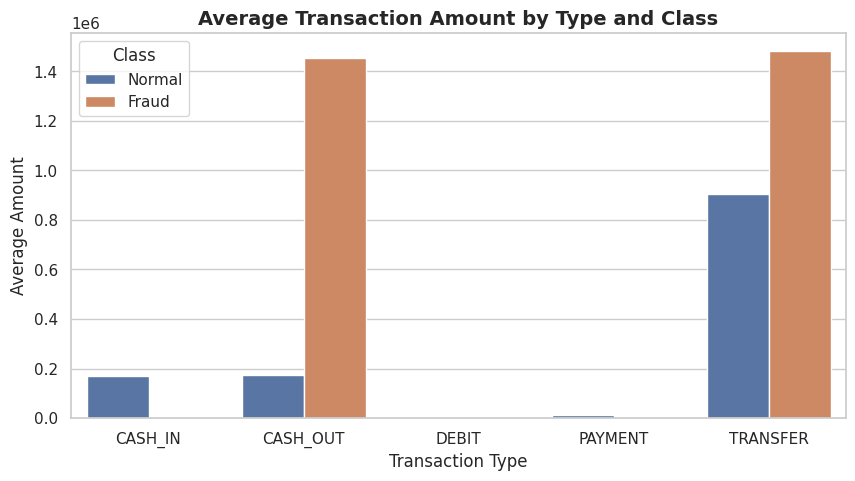

In [ ]:
# ---------------------------------------------------------
# Step 19: Average Transaction Amount by Type Plot
# ---------------------------------------------------------
# This plot compares average amount across transaction types
# for normal and fraud transactions.

plt.figure(figsize=(10, 5))

sns.barplot(
    data=avg_amount_type_class,
    x="type",
    y="amount",
    hue="Class"
)

plt.title("Average Transaction Amount by Type and Class", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount")

plt.show()

## Observation

Transaction amount is an important feature because fraud transactions may show different amount behavior compared to normal transactions.

However, amount alone is not enough to detect fraud.

We also need to analyze balance changes before and after the transaction.

In [ ]:
# ---------------------------------------------------------
# Step 20: Create Sender Balance Difference
# ---------------------------------------------------------
# Sender balance difference tells how much money was reduced
# from the sender account.
#
# Formula:
# balanceDiffOrig = oldbalanceOrg - newbalanceOrig

eda_df["balanceDiffOrig"] = eda_df["oldbalanceOrg"] - eda_df["newbalanceOrig"]

eda_df[["oldbalanceOrg", "newbalanceOrig", "balanceDiffOrig", "amount", "isFraud"]].head()

,oldbalanceOrg,newbalanceOrig,balanceDiffOrig,amount,isFraud
0,0.0000,0.0000,0.0000,2295.9800,0
1,1666154.2900,1786442.2300,-120287.9400,120287.9400,0
2,0.0000,0.0000,0.0000,471086.3000,0
3,0.0000,0.0000,0.0000,123429.8600,0
4,0.0000,0.0000,0.0000,120410.6500,0


In [ ]:
# ---------------------------------------------------------
# Step 21: Sender Balance Difference Summary
# ---------------------------------------------------------
# This compares sender balance difference for normal and
# fraud transactions.

sender_diff_summary = eda_df.groupby("isFraud")["balanceDiffOrig"].describe()
sender_diff_summary.index = ["Normal Transactions", "Fraud Transactions"]

sender_diff_summary

,count,mean,std,min,25%,50%,75%,max
Normal Transactions,100000.0000,-22964.8055,106155.1250,-1225177.3300,0.0000,0.0000,10106.3325,2802396.1900
Fraud Transactions,8213.0000,1457274.9739,2396099.2020,0.0000,124582.5800,436317.4900,1503034.8600,10000000.0000


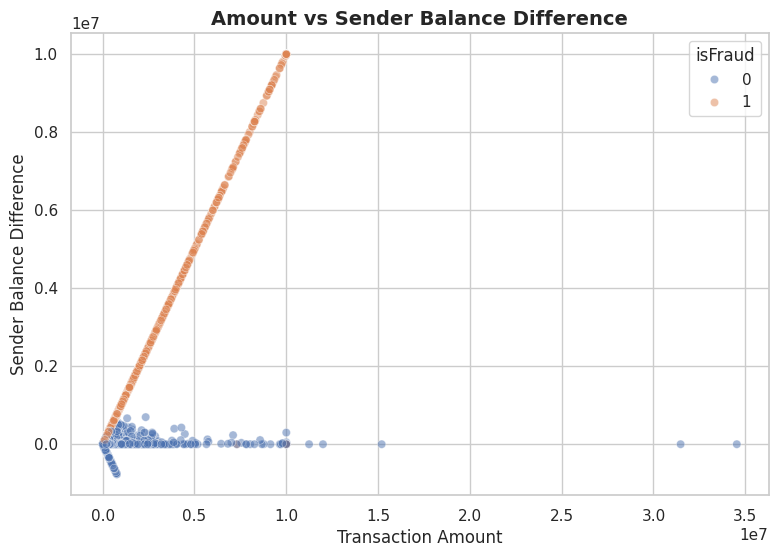

In [ ]:
# ---------------------------------------------------------
# Step 22: Sender Balance Difference vs Amount
# ---------------------------------------------------------
# This scatter plot checks the relationship between transaction
# amount and sender balance difference.

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=eda_df.sample(n=min(30000, len(eda_df)), random_state=42),
    x="amount",
    y="balanceDiffOrig",
    hue="isFraud",
    alpha=0.5
)

plt.title("Amount vs Sender Balance Difference", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Amount")
plt.ylabel("Sender Balance Difference")

plt.show()

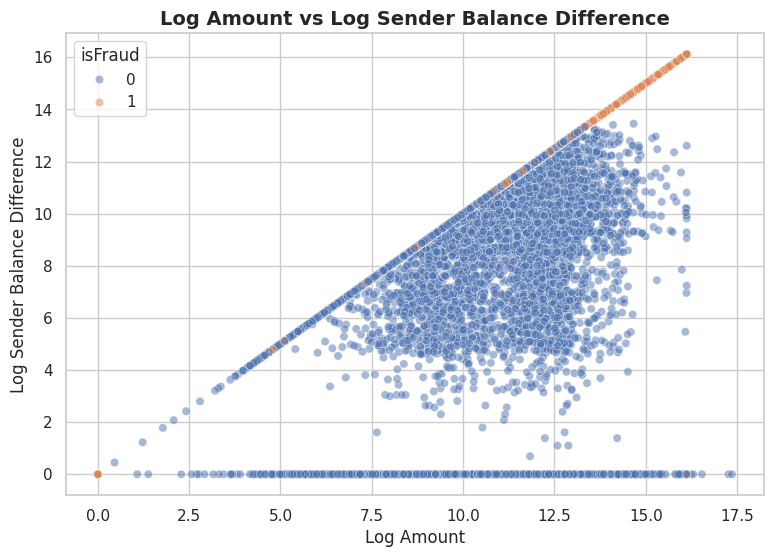

In [ ]:
# ---------------------------------------------------------
# Step 23: Log-Scaled Amount vs Sender Balance Difference
# ---------------------------------------------------------
# Since amount and balance differences can be large and skewed,
# we create log-transformed versions for better visualization.

eda_df["log_balanceDiffOrig"] = np.log1p(np.abs(eda_df["balanceDiffOrig"]))

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=eda_df.sample(n=min(30000, len(eda_df)), random_state=42),
    x="log_amount",
    y="log_balanceDiffOrig",
    hue="isFraud",
    alpha=0.5
)

plt.title("Log Amount vs Log Sender Balance Difference", fontsize=14, fontweight="bold")
plt.xlabel("Log Amount")
plt.ylabel("Log Sender Balance Difference")

plt.show()

In [ ]:
# ---------------------------------------------------------
# Step 24: Zero Sender Balance After Transaction
# ---------------------------------------------------------
# We check how often sender balance becomes zero after a transaction.
# This may be a useful suspicious pattern.

zero_balance_table = eda_df.groupby("isFraud")["newbalanceOrig"].apply(
    lambda x: (x == 0).sum()
).reset_index()

zero_balance_table.columns = ["isFraud", "Zero New Sender Balance Count"]

class_counts_sample = eda_df["isFraud"].value_counts().to_dict()

zero_balance_table["Total Transactions"] = zero_balance_table["isFraud"].map(class_counts_sample)

zero_balance_table["Zero Balance Percentage"] = (
    zero_balance_table["Zero New Sender Balance Count"] / zero_balance_table["Total Transactions"]
) * 100

zero_balance_table["Class"] = zero_balance_table["isFraud"].map({
    0: "Normal",
    1: "Fraud"
})

zero_balance_table

,isFraud,Zero New Sender Balance Count,Total Transactions,Zero Balance Percentage,Class
0,0,56931,100000,56.9310,Normal
1,1,8053,8213,98.0519,Fraud


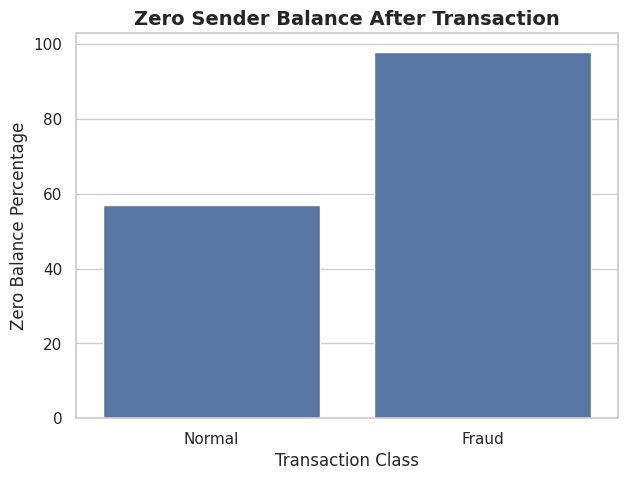

In [ ]:
# ---------------------------------------------------------
# Step 25: Zero Sender Balance Percentage Plot
# ---------------------------------------------------------
# This plot compares how often sender balance becomes zero
# in normal and fraud transactions.

plt.figure(figsize=(7, 5))

sns.barplot(
    data=zero_balance_table,
    x="Class",
    y="Zero Balance Percentage"
)

plt.title("Zero Sender Balance After Transaction", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Zero Balance Percentage")

plt.show()

## Observation

Sender balance behavior is very important for this project.

If the sender's balance becomes zero after a transaction, it may indicate suspicious behavior, especially when combined with high amount and transaction type.

In the next notebook, we will create a feature called:

`isZeroBalanceAfterTransaction`

In [ ]:
# ---------------------------------------------------------
# Step 26: Create Receiver Balance Difference
# ---------------------------------------------------------
# Receiver balance difference tells how much money was added
# to the receiver account.
#
# Formula:
# balanceDiffDest = newbalanceDest - oldbalanceDest

eda_df["balanceDiffDest"] = eda_df["newbalanceDest"] - eda_df["oldbalanceDest"]

eda_df[["oldbalanceDest", "newbalanceDest", "balanceDiffDest", "amount", "isFraud"]].head()

,oldbalanceDest,newbalanceDest,balanceDiffDest,amount,isFraud
0,0.0000,0.0000,0.0000,2295.9800,0
1,4554705.7500,4434417.8100,-120287.9400,120287.9400,0
2,611927.5100,1083013.8100,471086.3000,471086.3000,0
3,706827.0700,830256.9300,123429.8600,123429.8600,0
4,3280374.4400,3400785.0900,120410.6500,120410.6500,0


In [ ]:
# ---------------------------------------------------------
# Step 27: Receiver Balance Difference Summary
# ---------------------------------------------------------
# This compares receiver balance difference for normal and
# fraud transactions.

receiver_diff_summary = eda_df.groupby("isFraud")["balanceDiffDest"].describe()
receiver_diff_summary.index = ["Normal Transactions", "Fraud Transactions"]

receiver_diff_summary

,count,mean,std,min,25%,50%,75%,max
Normal Transactions,100000.0000,127768.2836,872880.4000,-1664863.3200,0.0000,0.0000,150254.9775,82704592.2600
Fraud Transactions,8213.0000,735457.9981,1856983.8560,-315226.0700,0.0000,0.0000,445257.4300,14915111.4700


In [31]:
# ---------------------------------------------------------
# Step 28: Create Log Receiver Balance Difference
# ---------------------------------------------------------
# We use absolute value before log transformation to avoid
# issues with negative values.

eda_df["log_balanceDiffDest"] = np.log1p(np.abs(eda_df["balanceDiffDest"]))

eda_df[["balanceDiffDest", "log_balanceDiffDest"]].head()

,balanceDiffDest,log_balanceDiffDest
0,0.0000,0.0000
1,-120287.9400,11.6977
2,471086.3000,13.0628
3,123429.8600,11.7234
4,120410.6500,11.6987


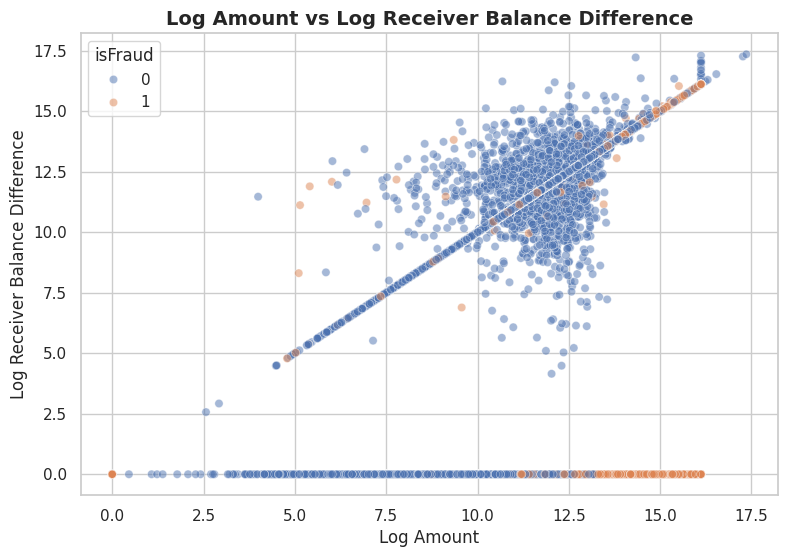

In [32]:
# ---------------------------------------------------------
# Step 29: Log Amount vs Log Receiver Balance Difference
# ---------------------------------------------------------
# This plot checks the relationship between transaction amount
# and receiver balance difference.

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=eda_df.sample(n=min(30000, len(eda_df)), random_state=42),
    x="log_amount",
    y="log_balanceDiffDest",
    hue="isFraud",
    alpha=0.5
)

plt.title("Log Amount vs Log Receiver Balance Difference", fontsize=14, fontweight="bold")
plt.xlabel("Log Amount")
plt.ylabel("Log Receiver Balance Difference")

plt.show()

## Observation

Receiver balance behavior can also help identify suspicious patterns.

If the receiver balance change does not match the transaction amount, it may indicate abnormal transaction behavior.

In the feature engineering notebook, we will create balance error features to capture such abnormal patterns.

In [33]:
# ---------------------------------------------------------
# Step 30: Create Balance Error Features
# ---------------------------------------------------------
# These features check whether balance changes mathematically
# match the transaction amount.
#
# Sender expected balance:
# oldbalanceOrg - amount = newbalanceOrig
#
# Receiver expected balance:
# oldbalanceDest + amount = newbalanceDest
#
# Any large difference may indicate abnormal behavior.

eda_df["errorBalanceOrig"] = eda_df["oldbalanceOrg"] - eda_df["amount"] - eda_df["newbalanceOrig"]
eda_df["errorBalanceDest"] = eda_df["oldbalanceDest"] + eda_df["amount"] - eda_df["newbalanceDest"]

eda_df[[
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "errorBalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "errorBalanceDest",
    "isFraud"
]].head()

,amount,oldbalanceOrg,newbalanceOrig,errorBalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceDest,isFraud
0,2295.9800,0.0000,0.0000,-2295.9800,0.0000,0.0000,2295.9800,0
1,120287.9400,1666154.2900,1786442.2300,-240575.8800,4554705.7500,4434417.8100,240575.8800,0
2,471086.3000,0.0000,0.0000,-471086.3000,611927.5100,1083013.8100,0.0000,0
3,123429.8600,0.0000,0.0000,-123429.8600,706827.0700,830256.9300,-0.0000,0
4,120410.6500,0.0000,0.0000,-120410.6500,3280374.4400,3400785.0900,0.0000,0


In [34]:
# ---------------------------------------------------------
# Step 31: Balance Error Summary
# ---------------------------------------------------------
# This compares balance error statistics for normal and fraud
# transactions.

error_orig_summary = eda_df.groupby("isFraud")["errorBalanceOrig"].describe()
error_dest_summary = eda_df.groupby("isFraud")["errorBalanceDest"].describe()

error_orig_summary.index = ["Normal Transactions", "Fraud Transactions"]
error_dest_summary.index = ["Normal Transactions", "Fraud Transactions"]

print("Sender Balance Error Summary:")
display(error_orig_summary)

print("\nReceiver Balance Error Summary:")
display(error_dest_summary)

Sender Balance Error Summary:


,count,mean,std,min,25%,50%,75%,max
Normal Transactions,100000.0000,-203481.8210,648212.1273,-69886731.3000,-249982.2325,-68794.9100,-3010.1825,0.0100
Fraud Transactions,8213.0000,-10692.3253,265146.1311,-10000000.0000,0.0000,0.0000,0.0000,0.0000



Receiver Balance Error Summary:


,count,mean,std,min,25%,50%,75%,max
Normal Transactions,100000.0000,52748.7319,460588.9604,-56308418.9100,0.0000,3496.2000,28973.0175,2458869.1700
Fraud Transactions,8213.0000,732509.3011,1867747.9906,-8875516.2900,0.0000,2231.4600,442722.0100,10000000.0000


In [35]:
# ---------------------------------------------------------
# Step 32: Create Log Balance Error Features
# ---------------------------------------------------------
# Log transformation helps visualize large error values clearly.

eda_df["log_errorBalanceOrig"] = np.log1p(np.abs(eda_df["errorBalanceOrig"]))
eda_df["log_errorBalanceDest"] = np.log1p(np.abs(eda_df["errorBalanceDest"]))

eda_df[["errorBalanceOrig", "log_errorBalanceOrig", "errorBalanceDest", "log_errorBalanceDest"]].head()

,errorBalanceOrig,log_errorBalanceOrig,errorBalanceDest,log_errorBalanceDest
0,-2295.9800,7.7394,2295.9800,7.7394
1,-240575.8800,12.3908,240575.8800,12.3908
2,-471086.3000,13.0628,0.0000,0.0000
3,-123429.8600,11.7234,-0.0000,0.0000
4,-120410.6500,11.6987,0.0000,0.0000


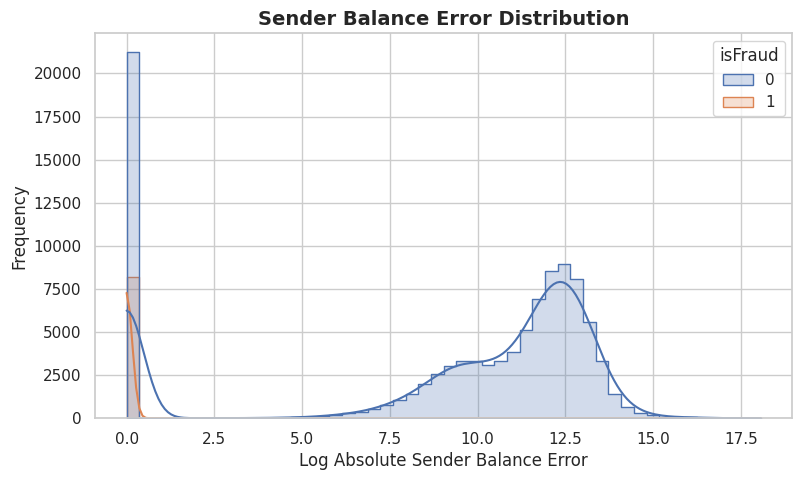

In [36]:
# ---------------------------------------------------------
# Step 33: Sender Balance Error Distribution
# ---------------------------------------------------------
# This plot compares sender balance error for normal and fraud
# transactions.

plt.figure(figsize=(9, 5))

sns.histplot(
    data=eda_df,
    x="log_errorBalanceOrig",
    hue="isFraud",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Sender Balance Error Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Log Absolute Sender Balance Error")
plt.ylabel("Frequency")

plt.show()

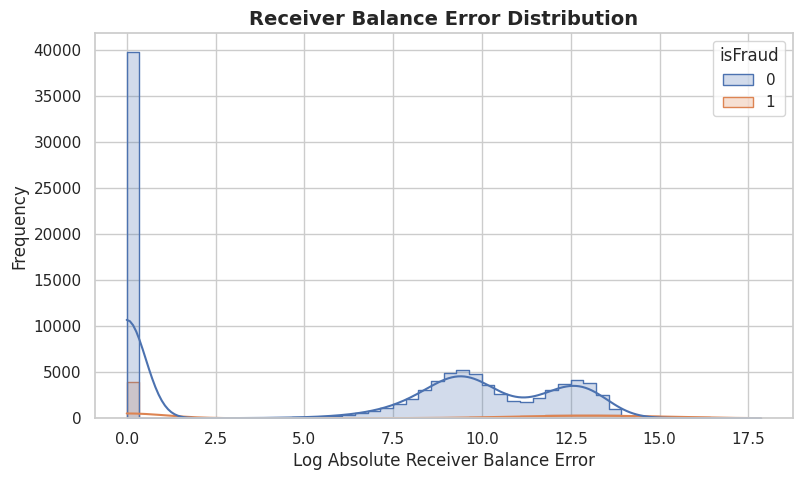

In [37]:
# ---------------------------------------------------------
# Step 34: Receiver Balance Error Distribution
# ---------------------------------------------------------
# This plot compares receiver balance error for normal and fraud
# transactions.

plt.figure(figsize=(9, 5))

sns.histplot(
    data=eda_df,
    x="log_errorBalanceDest",
    hue="isFraud",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Receiver Balance Error Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Log Absolute Receiver Balance Error")
plt.ylabel("Frequency")

plt.show()

## Observation

Balance error features can be useful because they capture abnormal changes in sender and receiver balances.

These engineered features may help the model learn fraud patterns better than using raw balance columns alone.

In Notebook 3, we will create these features properly for model training.

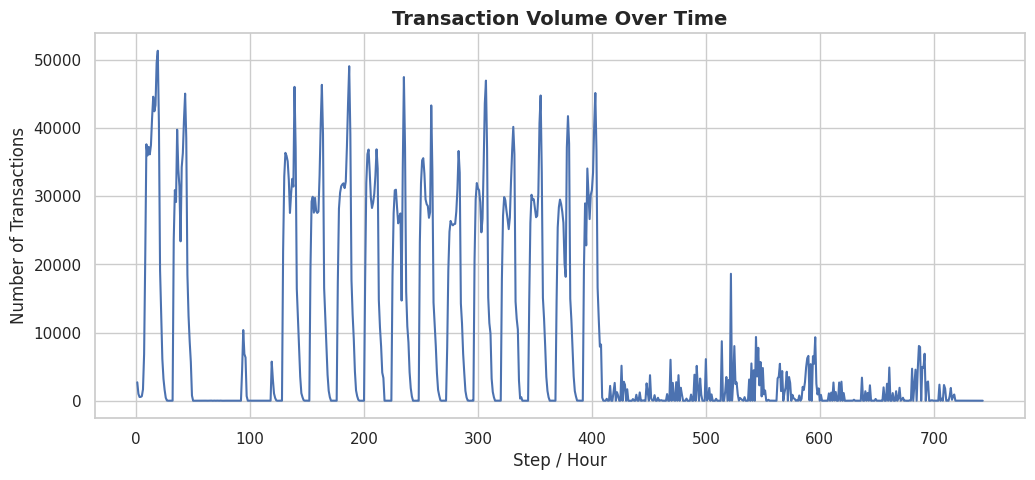

In [38]:
# ---------------------------------------------------------
# Step 35: Transactions Over Time
# ---------------------------------------------------------
# The step column represents time in hours.
# We analyze transaction volume over time.

transactions_over_time = df.groupby("step").size()

plt.figure(figsize=(12, 5))

transactions_over_time.plot()

plt.title("Transaction Volume Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Step / Hour")
plt.ylabel("Number of Transactions")

plt.show()

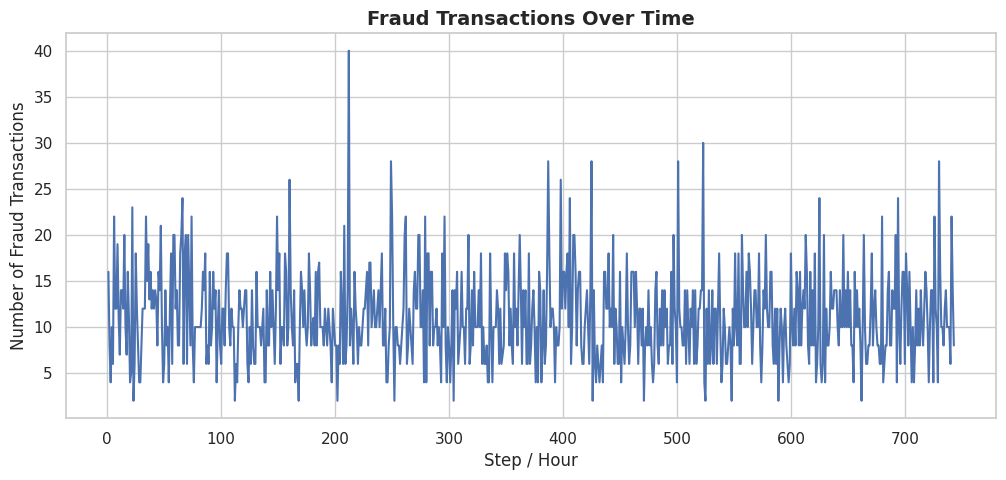

In [39]:
# ---------------------------------------------------------
# Step 36: Fraud Transactions Over Time
# ---------------------------------------------------------
# This plot shows how fraud transactions are distributed over time.

fraud_over_time = df[df["isFraud"] == 1].groupby("step").size()

plt.figure(figsize=(12, 5))

fraud_over_time.plot()

plt.title("Fraud Transactions Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Step / Hour")
plt.ylabel("Number of Fraud Transactions")

plt.show()

In [40]:
# ---------------------------------------------------------
# Step 37: Create Hour of Day Feature
# ---------------------------------------------------------
# Since each step represents one hour, we can create a rough
# hour-of-day feature using modulo 24.
#
# This may help us check whether fraud appears more during
# specific time periods.

eda_df["hourOfDay"] = eda_df["step"] % 24

eda_df[["step", "hourOfDay"]].head()

,step,hourOfDay
0,284,20
1,133,13
2,692,20
3,298,10
4,134,14


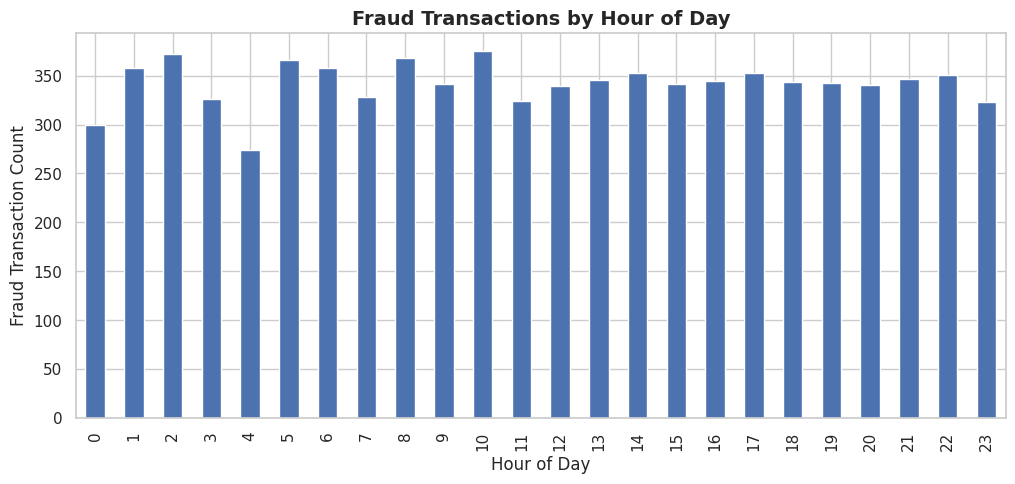

In [41]:
# ---------------------------------------------------------
# Step 38: Fraud by Hour of Day
# ---------------------------------------------------------
# This plot shows fraud count by estimated hour of day.

fraud_by_hour = eda_df[eda_df["isFraud"] == 1].groupby("hourOfDay").size()

plt.figure(figsize=(12, 5))

fraud_by_hour.plot(kind="bar")

plt.title("Fraud Transactions by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Transaction Count")

plt.show()

## Observation

The `step` column represents transaction time in hours.

Time-based features may provide extra information, but we need to test their usefulness during model training.

In Notebook 3, we may create an `hourOfDay` feature from the `step` column.

In [42]:
# ---------------------------------------------------------
# Step 39: Prepare Numerical Columns for Correlation
# ---------------------------------------------------------
# We select numerical columns including original and engineered
# EDA features to understand their relationships.

correlation_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balanceDiffOrig",
    "balanceDiffDest",
    "errorBalanceOrig",
    "errorBalanceDest",
    "isFraud"
]

corr_df = eda_df[correlation_columns]

corr_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiffOrig,balanceDiffDest,errorBalanceOrig,errorBalanceDest,isFraud
0,284,2295.9800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-2295.9800,2295.9800,0
1,133,120287.9400,1666154.2900,1786442.2300,4554705.7500,4434417.8100,-120287.9400,-120287.9400,-240575.8800,240575.8800,0
2,692,471086.3000,0.0000,0.0000,611927.5100,1083013.8100,0.0000,471086.3000,-471086.3000,0.0000,0
3,298,123429.8600,0.0000,0.0000,706827.0700,830256.9300,0.0000,123429.8600,-123429.8600,-0.0000,0
4,134,120410.6500,0.0000,0.0000,3280374.4400,3400785.0900,0.0000,120410.6500,-120410.6500,0.0000,0


In [43]:
# ---------------------------------------------------------
# Step 40: Correlation Matrix
# ---------------------------------------------------------
# Correlation shows relationships between numerical variables.
# Values near +1 or -1 indicate strong relationships.

correlation_matrix = corr_df.corr()

correlation_matrix

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiffOrig,balanceDiffDest,errorBalanceOrig,errorBalanceDest,isFraud
step,1.0000,0.0997,0.0114,-0.0222,0.0130,0.0226,0.1235,0.0405,-0.0008,0.0796,0.2155
amount,0.0997,1.0000,0.2196,0.0173,0.1754,0.3569,0.7594,0.7440,-0.5994,0.3198,0.3532
oldbalanceOrg,0.0114,0.2196,1.0000,0.9637,0.0510,0.0515,0.2414,0.0185,-0.0398,0.2756,0.0762
newbalanceOrig,-0.0222,0.0173,0.9637,1.0000,0.0609,0.0328,-0.0264,-0.0864,-0.0590,0.1463,-0.0607
oldbalanceDest,0.0130,0.1754,0.0510,0.0609,1.0000,0.9659,-0.0305,0.1948,-0.3065,-0.0351,-0.0426
newbalanceDest,0.0226,0.3569,0.0515,0.0328,0.9659,1.0000,0.0734,0.4423,-0.4570,-0.1365,0.0037
balanceDiffOrig,0.1235,0.7594,0.2414,-0.0264,-0.0305,0.0734,1.0000,0.3835,0.0655,0.5002,0.5062
balanceDiffDest,0.0405,0.7440,0.0185,-0.0864,0.1948,0.4423,0.3835,1.0000,-0.6692,-0.3952,0.1616
errorBalanceOrig,-0.0008,-0.5994,-0.0398,-0.0590,-0.3065,-0.4570,0.0655,-0.6692,1.0000,0.1249,0.0811
errorBalanceDest,0.0796,0.3198,0.2756,0.1463,-0.0351,-0.1365,0.5002,-0.3952,0.1249,1.0000,0.2563


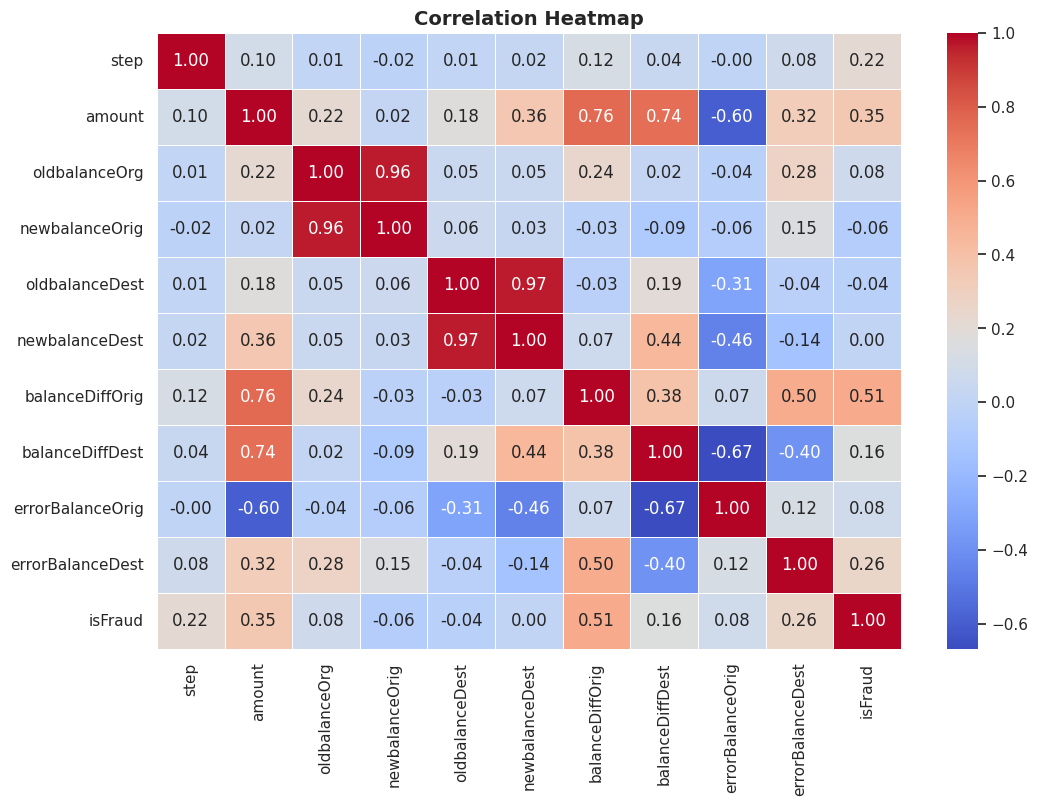

In [44]:
# ---------------------------------------------------------
# Step 41: Correlation Heatmap
# ---------------------------------------------------------
# This heatmap visually shows correlation between numerical features.

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.show()

In [45]:
# ---------------------------------------------------------
# Step 42: Correlation with Target Variable
# ---------------------------------------------------------
# This shows which numerical features have higher correlation
# with the target variable isFraud.

target_correlation = correlation_matrix["isFraud"].sort_values(ascending=False)

target_correlation

,isFraud
isFraud,1.0000
balanceDiffOrig,0.5062
amount,0.3532
errorBalanceDest,0.2563
step,0.2155
balanceDiffDest,0.1616
errorBalanceOrig,0.0811
oldbalanceOrg,0.0762
newbalanceDest,0.0037
oldbalanceDest,-0.0426


## Observation

Correlation helps us understand linear relationships between numerical features and the target variable.

However, fraud detection patterns can be non-linear, so low correlation does not mean a feature is useless.

Tree-based models like Decision Tree, Random Forest, and XGBoost can capture non-linear patterns better.

In [46]:
# ---------------------------------------------------------
# Step 43: Create Feature Ideas Table
# ---------------------------------------------------------
# Based on EDA, we list the features that can be useful
# for model training and risk explanation.

feature_ideas = pd.DataFrame({
    "Feature": [
        "type",
        "amount",
        "balanceDiffOrig",
        "balanceDiffDest",
        "errorBalanceOrig",
        "errorBalanceDest",
        "isZeroBalanceAfterTransaction",
        "hourOfDay",
        "isHighAmount"
    ],
    "Reason": [
        "Some transaction types show higher fraud patterns.",
        "Fraud transactions may have different amount behavior.",
        "Captures money deducted from sender account.",
        "Captures money added to receiver account.",
        "Checks mismatch in expected sender balance.",
        "Checks mismatch in expected receiver balance.",
        "Sender balance becoming zero can be suspicious.",
        "Time-based transaction behavior may be useful.",
        "Large amount transactions may carry higher risk."
    ]
})

feature_ideas

,Feature,Reason
0,type,Some transaction types show higher fraud patte...
1,amount,Fraud transactions may have different amount b...
2,balanceDiffOrig,Captures money deducted from sender account.
3,balanceDiffDest,Captures money added to receiver account.
4,errorBalanceOrig,Checks mismatch in expected sender balance.
5,errorBalanceDest,Checks mismatch in expected receiver balance.
6,isZeroBalanceAfterTransaction,Sender balance becoming zero can be suspicious.
7,hourOfDay,Time-based transaction behavior may be useful.
8,isHighAmount,Large amount transactions may carry higher risk.


In [47]:
# ---------------------------------------------------------
# Step 44: Save EDA Sample
# ---------------------------------------------------------
# We save the EDA sample for faster access later if required.
# This is not the final training dataset.

EDA_SAMPLE_PATH = os.path.join(PROCESSED_DATA_DIR, "eda_sample.csv")

eda_df.to_csv(EDA_SAMPLE_PATH, index=False)

print("EDA sample saved successfully.")
print("Saved path:", EDA_SAMPLE_PATH)

EDA sample saved successfully.
Saved path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/data/processed/eda_sample.csv


In [48]:
# ---------------------------------------------------------
# Step 45: Create EDA Observations
# ---------------------------------------------------------
# These observations summarize the important findings from EDA.
# They will be saved into a report file.

eda_observations = []

eda_observations.append("The dataset is highly imbalanced with very few fraud transactions compared to normal transactions.")
eda_observations.append("Transaction type is an important feature because fraud cases are concentrated in specific transaction types.")
eda_observations.append("Transaction amount shows different behavior between fraud and normal transactions.")
eda_observations.append("Sender balance difference may help identify suspicious balance changes.")
eda_observations.append("Sender balance becoming zero after transaction can be a useful risk signal.")
eda_observations.append("Receiver balance difference and receiver balance error may help capture abnormal receiver-side behavior.")
eda_observations.append("Balance error features can be useful because they compare expected and actual balance changes.")
eda_observations.append("The step column can be converted into hour-of-day to create a time-based feature.")
eda_observations.append("Correlation analysis is useful, but non-linear models may capture fraud patterns better than linear correlation suggests.")
eda_observations.append("Feature engineering is required before model training to improve fraud detection performance.")

for i, obs in enumerate(eda_observations, start=1):
    print(f"{i}. {obs}")

1. The dataset is highly imbalanced with very few fraud transactions compared to normal transactions.
2. Transaction type is an important feature because fraud cases are concentrated in specific transaction types.
3. Transaction amount shows different behavior between fraud and normal transactions.
4. Sender balance difference may help identify suspicious balance changes.
5. Sender balance becoming zero after transaction can be a useful risk signal.
6. Receiver balance difference and receiver balance error may help capture abnormal receiver-side behavior.
7. Balance error features can be useful because they compare expected and actual balance changes.
8. The step column can be converted into hour-of-day to create a time-based feature.
9. Correlation analysis is useful, but non-linear models may capture fraud patterns better than linear correlation suggests.
10. Feature engineering is required before model training to improve fraud detection performance.


In [49]:
# ---------------------------------------------------------
# Step 46: Save EDA Report
# ---------------------------------------------------------
# We save all key EDA observations into a text report file
# inside the reports folder.

eda_report_path = os.path.join(REPORTS_DIR, "02_eda_visualization_report.txt")

with open(eda_report_path, "w") as file:
    file.write("UPI Shield AI — EDA Visualization Report\n")
    file.write("=" * 50 + "\n\n")

    file.write("Dataset Used:\n")
    file.write(f"Raw dataset path: {DATA_PATH}\n")
    file.write(f"EDA sample shape: {eda_df.shape}\n\n")

    file.write("Class Distribution - Full Dataset:\n")
    file.write(str(fraud_percentage_table))
    file.write("\n\n")

    file.write("Transaction Type Summary:\n")
    file.write(str(type_summary))
    file.write("\n\n")

    file.write("Fraud by Transaction Type:\n")
    file.write(str(fraud_by_type))
    file.write("\n\n")

    file.write("Amount Summary:\n")
    file.write(str(amount_summary))
    file.write("\n\n")

    file.write("Zero Balance Summary:\n")
    file.write(str(zero_balance_table))
    file.write("\n\n")

    file.write("Feature Ideas:\n")
    file.write(str(feature_ideas))
    file.write("\n\n")

    file.write("EDA Observations:\n")
    for i, obs in enumerate(eda_observations, start=1):
        file.write(f"{i}. {obs}\n")

print("EDA report saved successfully.")
print("Report path:", eda_report_path)

EDA report saved successfully.
Report path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports/02_eda_visualization_report.txt


In [50]:
# ---------------------------------------------------------
# Step 47: Final Notebook Summary
# ---------------------------------------------------------
# This confirms that Notebook 2 has been completed.

print("Notebook 2: EDA Visualization completed successfully.")

print("\nKey Outputs:")
print("- Class imbalance visualized")
print("- Transaction type distribution analyzed")
print("- Fraud by transaction type analyzed")
print("- Amount behavior studied")
print("- Sender balance behavior studied")
print("- Receiver balance behavior studied")
print("- Balance error patterns analyzed")
print("- Time-based behavior analyzed")
print("- Correlation heatmap created")
print("- Feature ideas generated")
print("- EDA report saved")

print("\nNext Notebook:")
print("03_feature_engineering.ipynb")

Notebook 2: EDA Visualization completed successfully.

Key Outputs:
- Class imbalance visualized
- Transaction type distribution analyzed
- Fraud by transaction type analyzed
- Amount behavior studied
- Sender balance behavior studied
- Receiver balance behavior studied
- Balance error patterns analyzed
- Time-based behavior analyzed
- Correlation heatmap created
- Feature ideas generated
- EDA report saved

Next Notebook:
03_feature_engineering.ipynb


# Notebook 2 Summary

In this notebook, we performed Exploratory Data Analysis on the transaction fraud dataset.

## Key Findings

1. The dataset is highly imbalanced, with fraud transactions being very rare.
2. Fraud transactions are concentrated in specific transaction types.
3. Transaction amount shows different behavior for fraud and normal transactions.
4. Sender balance becoming zero after a transaction can be an important suspicious signal.
5. Balance difference and balance error features can help capture abnormal transaction behavior.
6. Time-based features may provide additional information.
7. Feature engineering is required before model training.

## Features Planned for Notebook 3

In the next notebook, we will create the following features:

- `balanceDiffOrig`
- `balanceDiffDest`
- `errorBalanceOrig`
- `errorBalanceDest`
- `isZeroBalanceAfterTransaction`
- `isHighAmount`
- `hourOfDay`

## Next Step

The next notebook will be:

`03_feature_engineering.ipynb`